In [15]:
import os
import sys
sys.path.append(os.path.dirname(os.getcwd()))
from data_provider.data_loader import FLAAPLoader
from types import SimpleNamespace

import numpy as np
import pandas as pd
import seaborn as sns
import math

In [6]:
data_name = "FLAAP"
args = dict(
    root_path = "/data/yoom618/TSLib/dataset/{}",
)

args = SimpleNamespace(**args)

train_dataset = FLAAPLoader(
    args=args,
    root_path=args.root_path.format(data_name),
    flag="TRAIN",
)

valid_dataset = FLAAPLoader(
    args=args,
    root_path=args.root_path.format(data_name),
    flag="VAL",
)


test_dataset = FLAAPLoader(
    args=args,
    root_path=args.root_path.format(data_name),
    flag="TEST",
)

In [7]:
train_dataset.max_seq_len

100

In [40]:
train_dataset.X.shape

(7873, 100, 6)

In [41]:
(train_dataset.X == 0).sum(axis=1)

array([[ 0,  0,  0,  0,  0, 18],
       [ 0,  0,  0,  1,  0,  1],
       [ 0,  0,  0,  0,  0,  0],
       ...,
       [ 0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  2,  1,  2],
       [ 0,  0,  0,  0,  0,  1]], shape=(7873, 6))

In [21]:
df1 = train_dataset.y.copy()
df2 = valid_dataset.y.copy()
df3 = test_dataset.y.copy()

log_2(N_class) : 3.321928094887362
-log_2(p_min) : 4.038815917150577


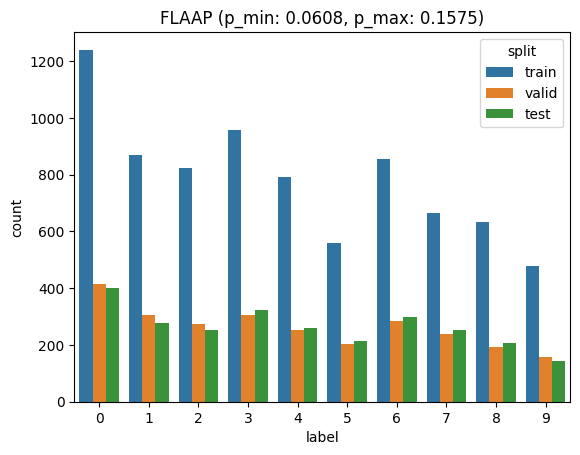

In [34]:
df = pd.DataFrame(np.concatenate([df1, df2, df3]), columns=["label"])
df["split"] = ["train"] * len(df1) + ["valid"] * len(df2) + ["test"] * len(df3)
train_count = np.unique(train_dataset.y, return_counts=True)[1]

fig = sns.countplot(x="label", hue="split", data=df)
fig.set_title(f"{data_name} (p_min: {
    (train_count).min()/len(df1):.4f}, p_max: {
    train_count.max()/len(df1):.4f})")
# display(fig.get_figure())


print(f'log_2(N_class) : {math.log2(len(train_count))}')
print(f'-log_2(p_min) : {-math.log2(train_count.min()/len(df1))}')